In [15]:
# %% [markdown]
# 05_model_tuning and insights — stable feature set for Streamlit

# %%
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance
import joblib

# Paths
DATA_PATH   = "../data/processed/cleaned.csv"
MODEL_PATH  = "../models/best_model.pkl"
MANIFEST_PATH = "../models/feature_manifest.json"

# Choose feature set
FEATURE_SET = "small"  # "small" (13 features) or "full"

SMALL_FEATURES = [
    "Age", "DistanceFromHome", "MonthlyIncome", "TotalWorkingYears",
    "YearsAtCompany", "JobSatisfaction", "EnvironmentSatisfaction",
    "WorkLifeBalance", "OverTime_encoded", "Gender_encoded",
    "MaritalStatus_Divorced", "MaritalStatus_Married", "MaritalStatus_Single"
]


In [16]:
# %%
df = pd.read_csv(DATA_PATH)

# Target
y = df["Attrition_encoded"]

# Feature selection
if FEATURE_SET == "small":
    X = df[SMALL_FEATURES].copy()
else:
    # Use everything numeric/encoded except the target
    EXCLUDE = {"Attrition", "Attrition_encoded"}
    X = df[[c for c in df.columns if c not in EXCLUDE]].copy()

print("Dataset shape:", df.shape)
print("Feature set:", FEATURE_SET)
print("X shape:", X.shape, " | y shape:", y.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Dataset shape: (1470, 50)
Feature set: small
X shape: (1470, 13)  | y shape: (1470,)
Train shape: (1176, 13) Test shape: (294, 13)


In [17]:
# %%
# Identify numeric columns to scale (ints/floats that are not one-hot flags)
# In the small set, these are the first 8; the rest are 0/1 flags.
if FEATURE_SET == "small":
    numeric_cols = [
        "Age", "DistanceFromHome", "MonthlyIncome", "TotalWorkingYears",
        "YearsAtCompany", "JobSatisfaction", "EnvironmentSatisfaction",
        "WorkLifeBalance"
    ]
else:
    # Heuristic: scale columns that are not already one-hot (0/1) flags by checking variance > 1
    numeric_cols = []
    for c in X_train.columns:
        if pd.api.types.is_numeric_dtype(X_train[c]):
            # consider it "continuous" if it has more than 10 unique values or std > 1
            if X_train[c].nunique() > 10 or X_train[c].std() > 1.0:
                numeric_cols.append(c)

preprocess = ColumnTransformer(
    transformers=[("scale", StandardScaler(), numeric_cols)],
    remainder="passthrough"
)

print("Numeric columns to scale:", numeric_cols)


Numeric columns to scale: ['Age', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance']


In [18]:
# %%
# Logistic Regression (with class_weight to help imbalance)
log_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, n_jobs=None, class_weight="balanced"))
])

log_grid = {
    "model__C": [0.05, 0.1, 0.5, 1, 2],
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ["l2"]
}

# Random Forest
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8, 14],
    "model__min_samples_split": [2, 5, 10],
    "model__class_weight": [None, "balanced"]
}


In [19]:
# %%
def tune(name, pipe, grid, X_tr, y_tr):
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )
    gs.fit(X_tr, y_tr)
    print(f"\n===== {name} — Best Params =====")
    print(gs.best_params_)
    print("Best CV ROC-AUC:", round(gs.best_score_, 4))
    return gs.best_estimator_

log_best = tune("Logistic Regression", log_pipe, log_grid, X_train, y_train)
rf_best  = tune("Random Forest", rf_pipe, rf_grid, X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits

===== Logistic Regression — Best Params =====
{'model__C': 0.05, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.775
Fitting 5 folds for each of 36 candidates, totalling 180 fits

===== Random Forest — Best Params =====
{'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.7781


In [20]:
# %%
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)

    print(f"\n===== {name} — Test Metrics =====")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(auc, 4))
    print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred))
    print("\nClassification Report:\n", classification_report(y_te, y_pred))

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}

res_log = evaluate("Logistic Regression", log_best, X_test, y_test)
res_rf  = evaluate("Random Forest", rf_best, X_test, y_test)

results_df = pd.DataFrame([res_log, res_rf]).sort_values("roc_auc", ascending=False)
results_df



===== Logistic Regression — Test Metrics =====
Accuracy: 0.7313
Precision: 0.3491
Recall: 0.7872
F1: 0.4837
ROC-AUC: 0.7896

Confusion Matrix:
 [[178  69]
 [ 10  37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.72      0.82       247
           1       0.35      0.79      0.48        47

    accuracy                           0.73       294
   macro avg       0.65      0.75      0.65       294
weighted avg       0.85      0.73      0.76       294


===== Random Forest — Test Metrics =====
Accuracy: 0.8435
Precision: 0.5238
Recall: 0.234
F1: 0.3235
ROC-AUC: 0.7949

Confusion Matrix:
 [[237  10]
 [ 36  11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.52      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.70      0.60      0.62       294
weighted avg       0.8

,model,accuracy,precision,recall,f1,roc_auc
1,Random Forest,0.843537,0.523810,0.234043,0.323529,0.794901
0,Logistic Regression,0.731293,0.349057,0.787234,0.483660,0.789560


In [22]:
# %%
best_row = results_df.iloc[0]
best_name = best_row["model"]
best_model = log_best if best_name == "Logistic Regression" else rf_best

print(f"\n🎉 Best model: {best_name} with ROC-AUC {best_row['roc_auc']:.4f}")

# Save pipeline (includes preprocessing)
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(best_model, MODEL_PATH)
print(f"✅ Saved best model to {MODEL_PATH}")

# Save feature manifest (raw columns the model expects at inference)
manifest = {
    "features": X_train.columns.tolist(),
    "feature_set": FEATURE_SET,
    "numeric_scaled": numeric_cols,
    "model_name": best_name
}
with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2)
print(f"✅ Saved feature manifest to {MANIFEST_PATH}")



🎉 Best model: Random Forest with ROC-AUC 0.7949
✅ Saved best model to ../models/best_model.pkl
✅ Saved feature manifest to ../models/feature_manifest.json


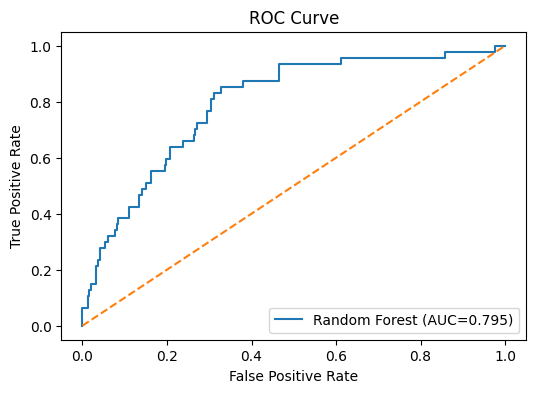

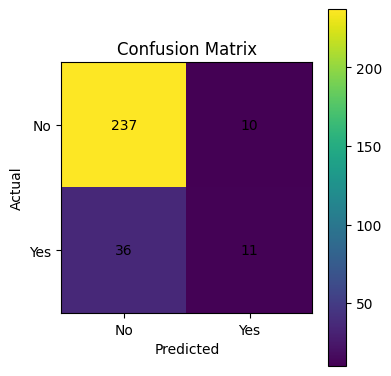

In [23]:
# %%
# ROC Curve for the best model
y_proba_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thr = roc_curve(y_test, y_proba_best)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"{best_name} (AUC={roc_auc_score(y_test, y_proba_best):.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Confusion Matrix (best model)
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["No", "Yes"])
plt.yticks(tick_marks, ["No", "Yes"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


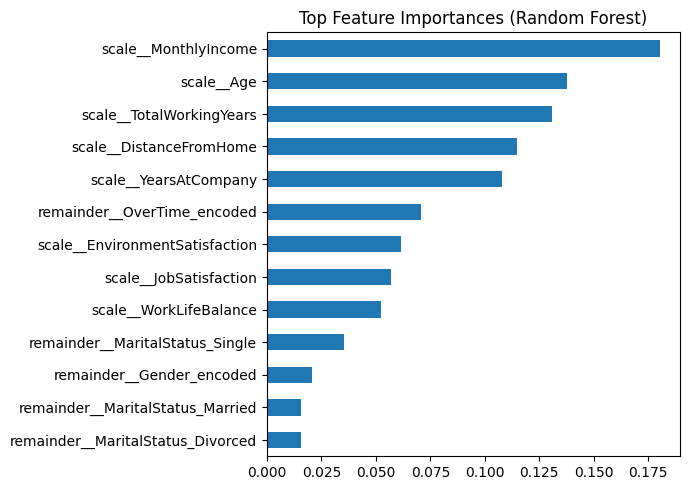

In [24]:
# %%
# Try to show model-specific importances/coefficients
try:
    if best_name == "Random Forest":
        importances = best_model.named_steps["model"].feature_importances_
        # get the post-preprocess feature names:
        raw_cols = X_train.columns.tolist()
        feat_imp = pd.Series(importances, index=best_model.named_steps["preprocess"].get_feature_names_out(raw_cols))
        top = feat_imp.sort_values(ascending=False).head(15)
        plt.figure(figsize=(7,5))
        top[::-1].plot(kind="barh")
        plt.title("Top Feature Importances (Random Forest)")
        plt.tight_layout()
        plt.show()
    else:
        # Logistic coefficients
        coefs = best_model.named_steps["model"].coef_.ravel()
        raw_cols = X_train.columns.tolist()
        feat_names = best_model.named_steps["preprocess"].get_feature_names_out(raw_cols)
        coef_s = pd.Series(coefs, index=feat_names).sort_values(key=np.abs, ascending=False).head(15)
        plt.figure(figsize=(7,5))
        coef_s[::-1].plot(kind="barh")
        plt.title("Top Coefficients (Logistic Regression)")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Feature importance plot skipped:", e)

# Optional: permutation importance (model-agnostic; slower)
# pi = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
# pi_s = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)
# plt.figure(figsize=(7,5))
# pi_s[::-1].plot(kind="barh")
# plt.title("Top Features (Permutation Importance)")
# plt.tight_layout()
# plt.show()
